In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df = pd.read_csv('wine_data.csv',header=None,usecols=[0,1,2],names=['class_label','Alcohol','Malic_Acid'])

In [20]:
x=df.iloc[:,1:]

In [21]:
y=df.iloc[:,0:1]

In [16]:
df.sample(5)

,class_label,Alcohol,Malic_Acid
86,2,12.16,1.61
111,2,12.52,2.43
131,3,12.88,2.99
153,3,13.23,3.30
117,2,12.42,1.61


<Axes: xlabel='Malic_Acid', ylabel='Alcohol'>

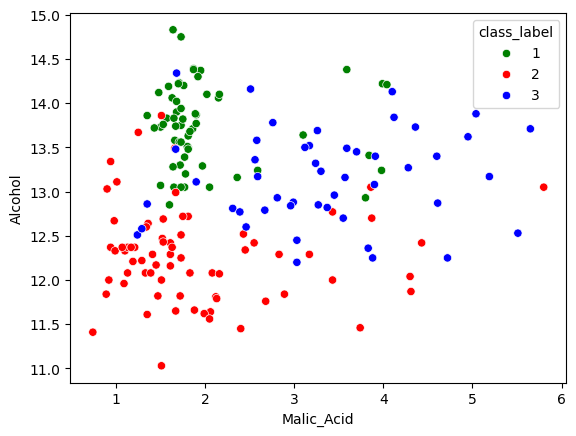

In [18]:
color_dict={1:'Green',2:'Red',3:'Blue'}
sns.scatterplot(x=df['Malic_Acid'],y=df['Alcohol'],hue=df['class_label'],palette=color_dict)

In [39]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_train = train_test_split(x, y, test_size=0.3, random_state=0)

In [40]:
x_train.shape, x_test.shape

((124, 2), (54, 2))

In [41]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(x_train)

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [42]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [43]:
np.round(x_train.describe(),1)

,Alcohol,Malic_Acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [44]:
np.round(x_train_scaled.describe(),1)

,Alcohol,Malic_Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'After Scaling')

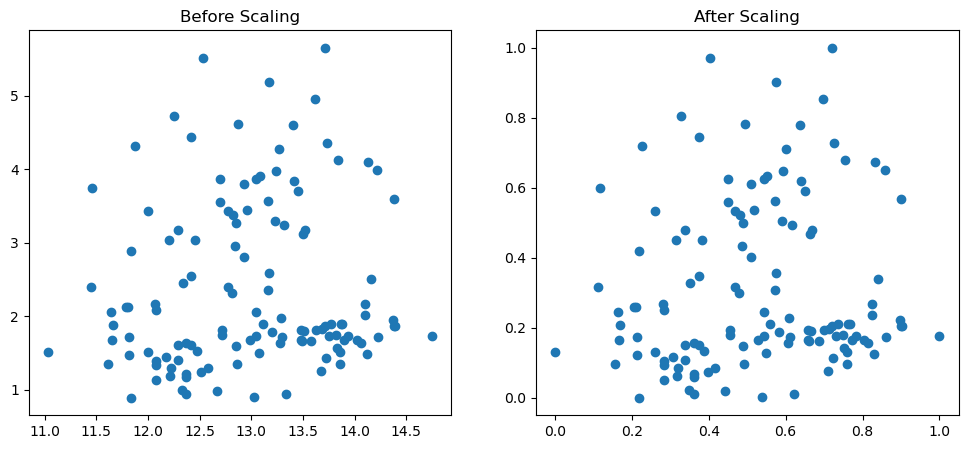

In [50]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train['Alcohol'],x_train['Malic_Acid'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled['Alcohol'],x_train_scaled['Malic_Acid'])
ax2.set_title("After Scaling")

<Axes: title={'center': 'After Scaling'}, xlabel='Alcohol', ylabel='Density'>

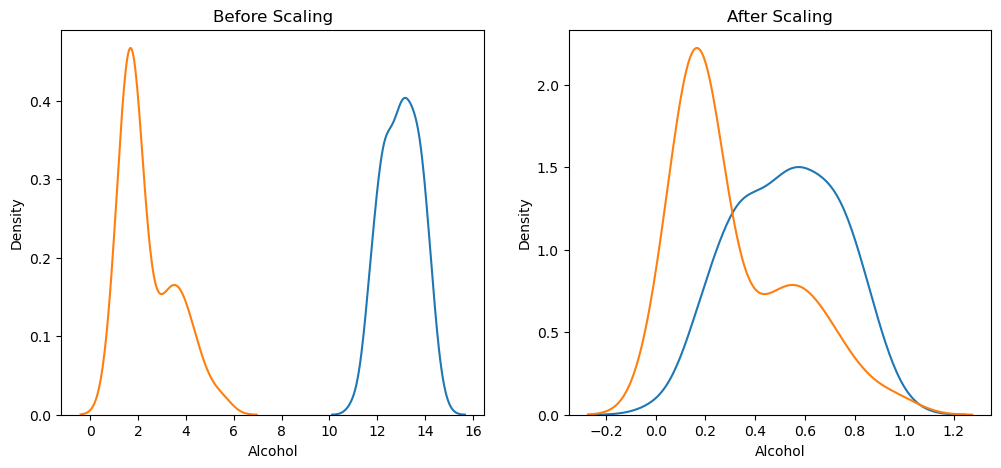

In [52]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Alcohol'],ax=ax1)
sns.kdeplot(x_train['Malic_Acid'],ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(x_train_scaled['Alcohol'],ax=ax2)
sns.kdeplot(x_train_scaled['Malic_Acid'],ax=ax2)